In [2]:
# ============================================================
# 2021 ABU DHABI GRAND PRIX — DATA ANALYSIS
# The Race That Decided a World Championship
# ============================================================
# 1. Install the FastF1 library
!pip install fastf1

# Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import seaborn as sns
import fastf1
import fastf1.plotting

# Cache setup
os.makedirs('f1_cache', exist_ok=True)
fastf1.Cache.enable_cache('f1_cache')
fastf1.plotting.setup_mpl(mpl_theme='dark', misc_mpl_mods=False)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 427.6/427.6 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: msgpack
    Found existing installation: msgpack 1.2.0
    Uninstalling msgpack-1.2.0:
      Successfully uninstalled msgpack-1.2.0


/usr/local/lib/python3.12/dist-packages/fastf1/plotting/_plotting.py:56: FutureWarning: The `misc_mpl_mods` argument was dropped from `.setup_mpl()` in version 3.6.0 and has no effect anymore. It will be removed in a future version of FastF1.
  warnings.warn(


In [3]:
# ============================================================
# DATA LOADING
# ============================================================
print("Loading 2021 Abu Dhabi GP session data...")
print("This may take 1-2 minutes on first run (full telemetry)")

session = fastf1.get_session(2021, 'Abu Dhabi', 'R')
session.load()

print(f"\nLoaded: {session.event['EventName']} {session.date.year}")
print(f"Total laps in dataset: {len(session.laps)}")


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...


Loading 2021 Abu Dhabi GP session data...
This may take 1-2 minutes on first run (full telemetry)


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	F


Loaded: Abu Dhabi Grand Prix 2021
Total laps in dataset: 1000


/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


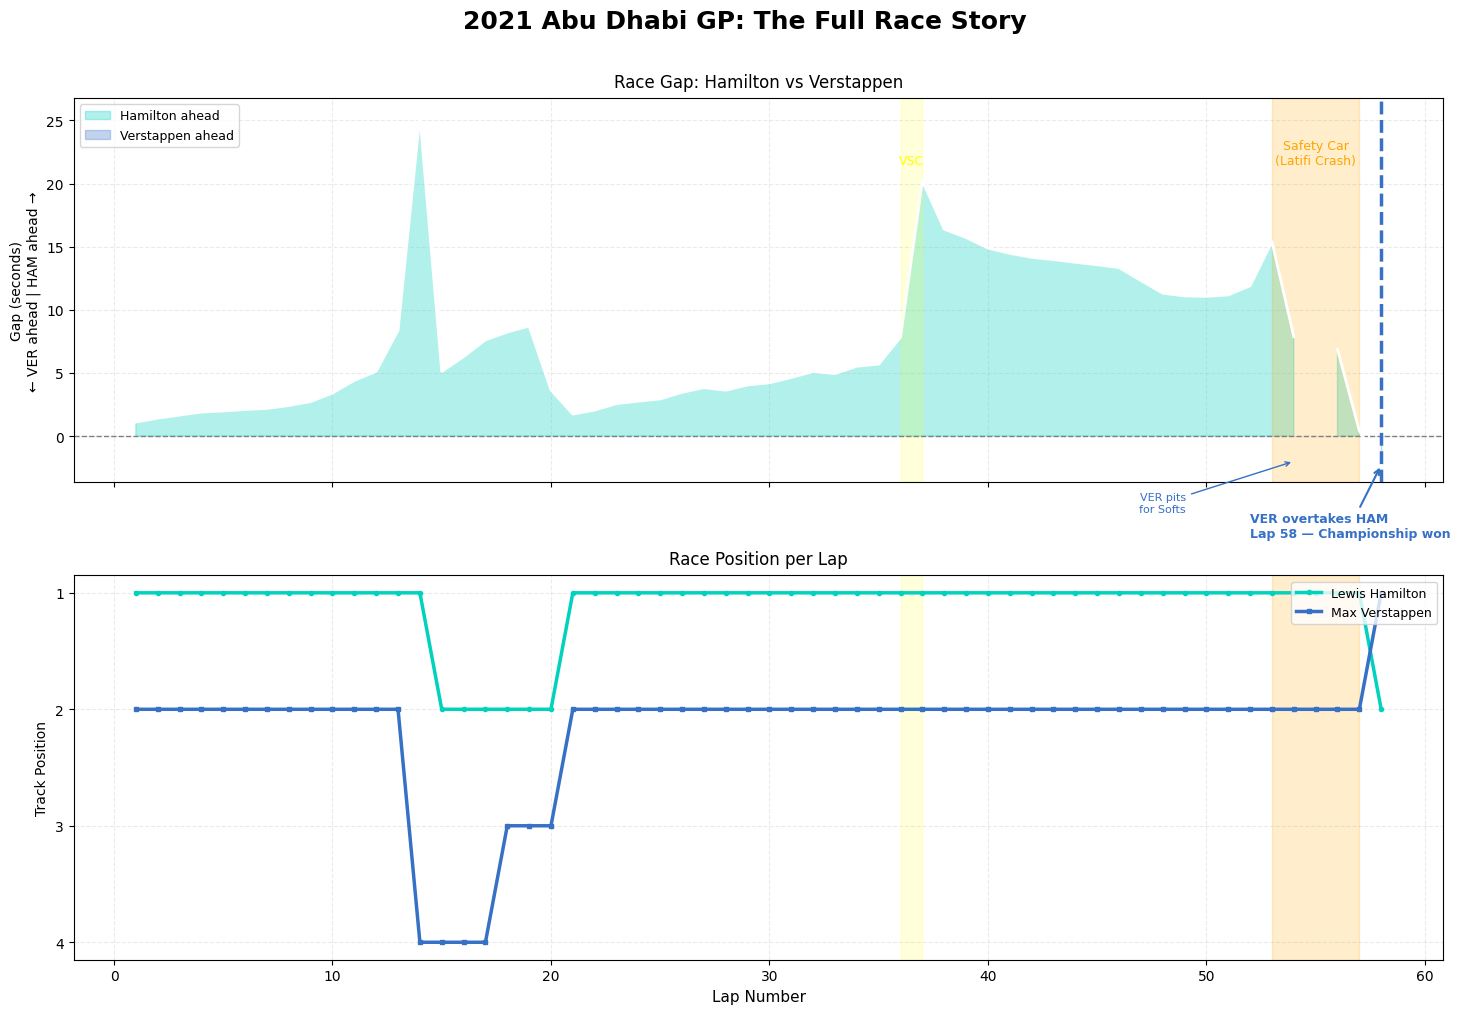

In [4]:
# ============================================================
# PHASE 0 — THE MACRO STORY
# Race Gap & Position Timeline
# ============================================================

ham_laps = session.laps.pick_driver('HAM').copy()
ver_laps = session.laps.pick_driver('VER').copy()

ham_laps['RaceTimeSec'] = ham_laps['LapStartTime'].dt.total_seconds() + ham_laps['LapTime'].dt.total_seconds()
ver_laps['RaceTimeSec'] = ver_laps['LapStartTime'].dt.total_seconds() + ver_laps['LapTime'].dt.total_seconds()

gap_df = pd.merge(
    ham_laps[['LapNumber', 'RaceTimeSec', 'Position']],
    ver_laps[['LapNumber', 'RaceTimeSec', 'Position']],
    on='LapNumber',
    suffixes=('_HAM', '_VER')
)
gap_df['GapSeconds'] = gap_df['RaceTimeSec_VER'] - gap_df['RaceTimeSec_HAM']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
fig.suptitle("2021 Abu Dhabi GP: The Full Race Story", fontsize=18, fontweight='bold', y=1.01)

# --- Panel 1: Gap ---
ax1.plot(gap_df['LapNumber'], gap_df['GapSeconds'], color='white', lw=2, zorder=3)
ax1.fill_between(gap_df['LapNumber'], gap_df['GapSeconds'], 0,
                 where=(gap_df['GapSeconds'] > 0), color='#00D2BE', alpha=0.3, label='Hamilton ahead')
ax1.fill_between(gap_df['LapNumber'], gap_df['GapSeconds'], 0,
                 where=(gap_df['GapSeconds'] < 0), color='#3671C6', alpha=0.3, label='Verstappen ahead')
ax1.axhline(0, color='gray', lw=1, linestyle='--')

ax1.axvspan(36, 37, color='yellow', alpha=0.15)
ax1.axvspan(53, 57, color='orange', alpha=0.2)
ax1.annotate('VSC', xy=(36.5, gap_df['GapSeconds'].max() * 0.85),
             color='yellow', fontsize=9, ha='center')
ax1.annotate('Safety Car\n(Latifi Crash)', xy=(55, gap_df['GapSeconds'].max() * 0.85),
             color='orange', fontsize=9, ha='center')
ax1.annotate('VER pits\nfor Softs', xy=(54, -2),
             color='#3671C6', fontsize=8, ha='center',
             arrowprops=dict(arrowstyle='->', color='#3671C6'),
             xytext=(48, -6))

# Final lap callout
ax1.axvline(x=58, color='#3671C6', lw=2.5, linestyle='--', zorder=4)
ax1.annotate(
    'VER overtakes HAM\nLap 58 — Championship won',
    xy=(58, gap_df.loc[gap_df['LapNumber'] == 58, 'GapSeconds'].values[0]),
    xytext=(52, -8),
    color='#3671C6', fontsize=9, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#3671C6', lw=1.5)
)

ax1.set_ylabel("Gap (seconds)\n← VER ahead | HAM ahead →", fontsize=10)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.25)
ax1.set_title("Race Gap: Hamilton vs Verstappen", fontsize=12, pad=8)

# --- Panel 2: Position ---
ax2.plot(ham_laps['LapNumber'], ham_laps['Position'],
         color='#00D2BE', lw=2.5, marker='o', markersize=3, label='Lewis Hamilton')
ax2.plot(ver_laps['LapNumber'], ver_laps['Position'],
         color='#3671C6', lw=2.5, marker='s', markersize=3, label='Max Verstappen')

ax2.axvspan(36, 37, color='yellow', alpha=0.15)
ax2.axvspan(53, 57, color='orange', alpha=0.2)
ax2.set_ylabel("Track Position", fontsize=10)
ax2.set_xlabel("Lap Number", fontsize=11)
ax2.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax2.invert_yaxis()
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.25)
ax2.set_title("Race Position per Lap", fontsize=12, pad=8)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


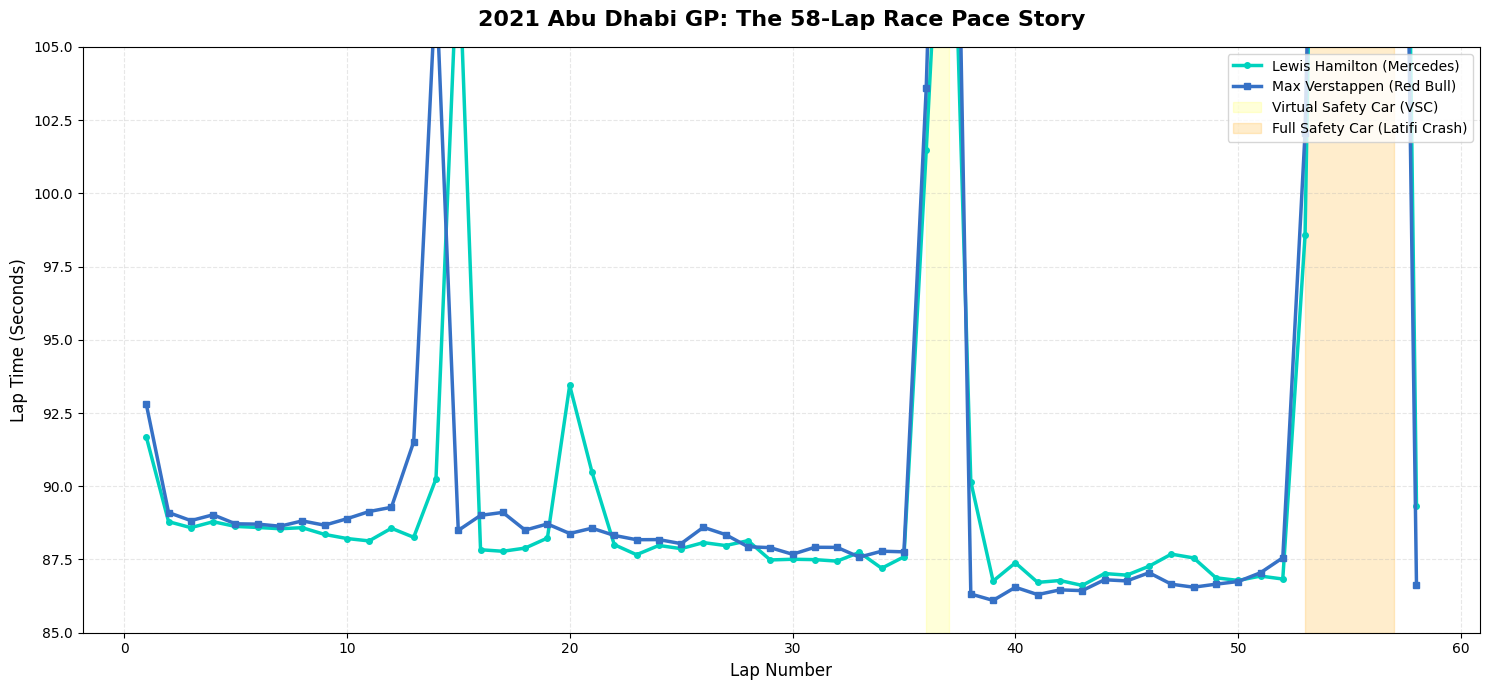

In [5]:
# ============================================================
# PHASE 1 — FULL RACE PACE ANALYSIS
# Every lap time across 58 laps
# ============================================================

ham_all_laps = session.laps.pick_driver('HAM').copy()
ver_all_laps = session.laps.pick_driver('VER').copy()
ham_all_laps['LapTimeSec'] = ham_all_laps['LapTime'].dt.total_seconds()
ver_all_laps['LapTimeSec'] = ver_all_laps['LapTime'].dt.total_seconds()

fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(ham_all_laps['LapNumber'], ham_all_laps['LapTimeSec'],
        label='Lewis Hamilton (Mercedes)', color='#00D2BE', lw=2.5, marker='o', markersize=4)
ax.plot(ver_all_laps['LapNumber'], ver_all_laps['LapTimeSec'],
        label='Max Verstappen (Red Bull)', color='#3671C6', lw=2.5, marker='s', markersize=4)

ax.axvspan(36, 37, color='yellow', alpha=0.15, label='Virtual Safety Car (VSC)')
ax.axvspan(53, 57, color='orange', alpha=0.2, label='Full Safety Car (Latifi Crash)')

ax.set_ylim(85, 105)
ax.set_title("2021 Abu Dhabi GP: The 58-Lap Race Pace Story", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Lap Number", fontsize=12)
ax.set_ylabel("Lap Time (Seconds)", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


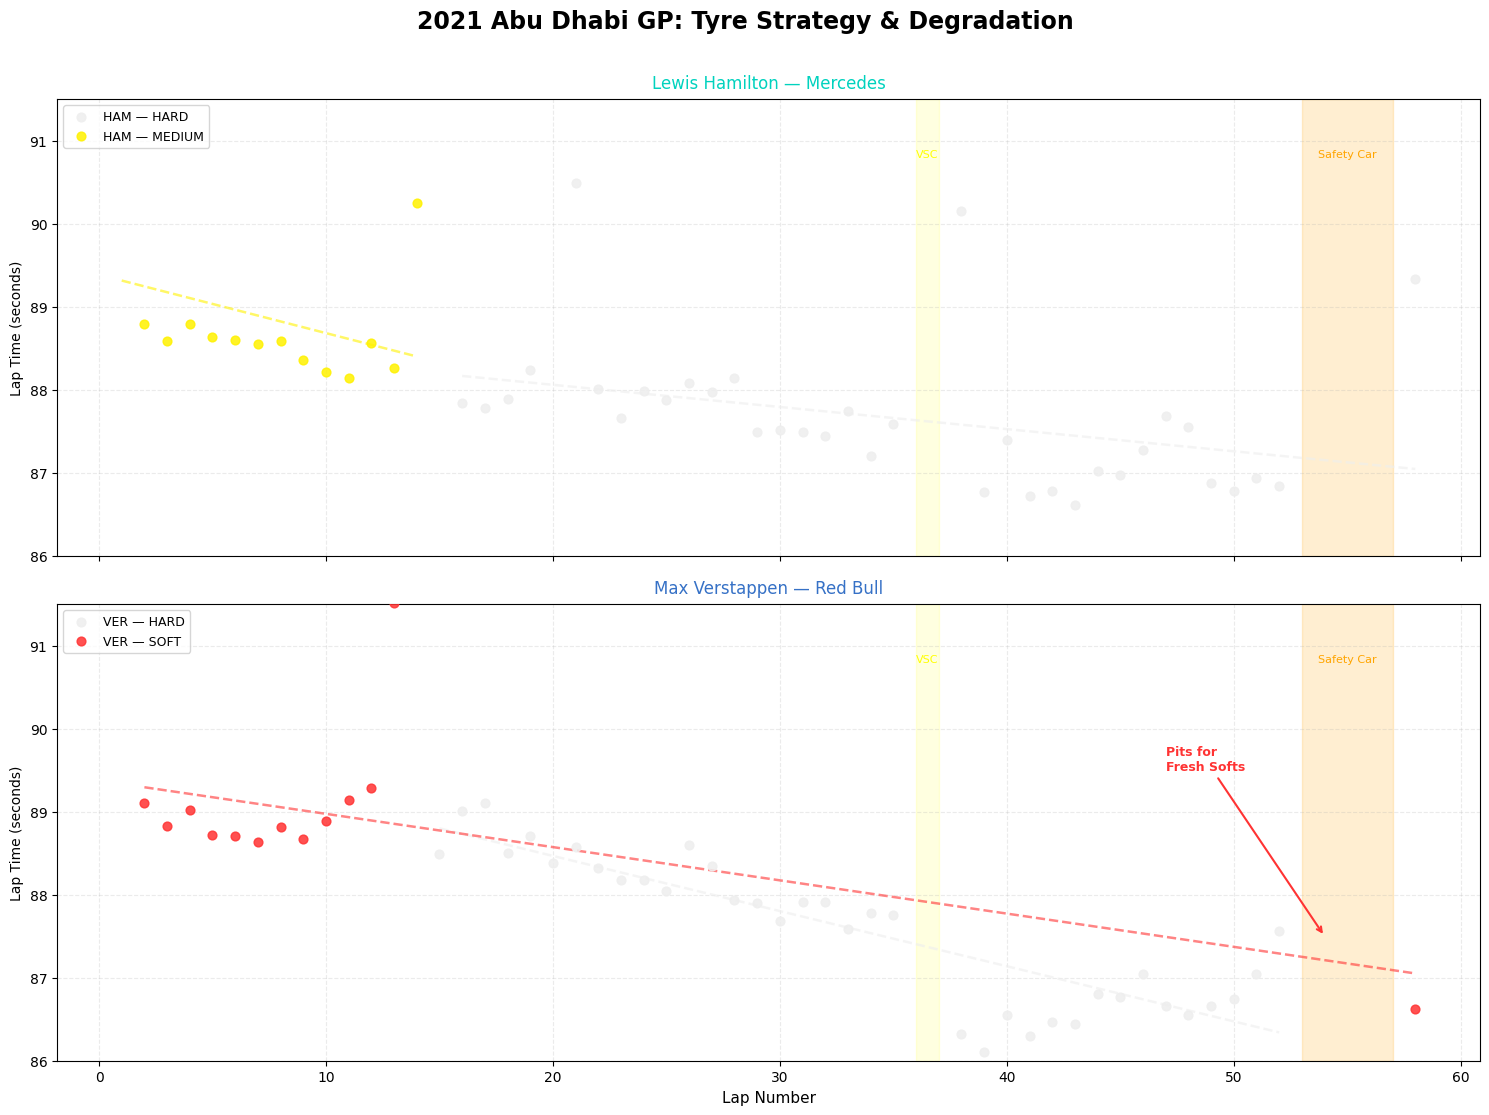

In [6]:
# ============================================================
# PHASE 2 — TYRE STRATEGY & DEGRADATION
# Compound choices, stint lengths and pace evolution
# ============================================================

quick_laps = session.laps.pick_quicklaps()
ham_quick = quick_laps.pick_driver('HAM').copy()
ver_quick = quick_laps.pick_driver('VER').copy()
ham_quick['LapTimeSec'] = ham_quick['LapTime'].dt.total_seconds()
ver_quick['LapTimeSec'] = ver_quick['LapTime'].dt.total_seconds()

compound_colors = {
    'SOFT':   '#FF3333',
    'MEDIUM': '#FFF200',
    'HARD':   '#EEEEEE',
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 11), sharex=True)
fig.suptitle("2021 Abu Dhabi GP: Tyre Strategy & Degradation", fontsize=17, fontweight='bold', y=1.01)

# --- Hamilton ---
for compound, group in ham_quick.groupby('Compound'):
    color = compound_colors.get(compound, 'white')
    ax1.scatter(group['LapNumber'], group['LapTimeSec'],
                color=color, label=f'HAM — {compound}', s=40, zorder=3, alpha=0.85)
    if len(group) > 2:
        z = np.polyfit(group['LapNumber'], group['LapTimeSec'], 1)
        p = np.poly1d(z)
        ax1.plot(group['LapNumber'], p(group['LapNumber']),
                 color=color, lw=1.8, linestyle='--', alpha=0.6)

ax1.axvspan(36, 37, color='yellow', alpha=0.12)
ax1.axvspan(53, 57, color='orange', alpha=0.18)
ax1.annotate('VSC', xy=(36.5, 90.8), color='yellow', fontsize=8, ha='center')
ax1.annotate('Safety Car', xy=(55, 90.8), color='orange', fontsize=8, ha='center')
ax1.set_ylabel("Lap Time (seconds)", fontsize=10)
ax1.set_title("Lewis Hamilton — Mercedes", fontsize=12, color='#00D2BE', pad=8)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.25)
ax1.set_ylim(86, 91.5)

# --- Verstappen ---
for compound, group in ver_quick.groupby('Compound'):
    color = compound_colors.get(compound, 'white')
    ax2.scatter(group['LapNumber'], group['LapTimeSec'],
                color=color, label=f'VER — {compound}', s=40, zorder=3, alpha=0.85)
    if len(group) > 2:
        z = np.polyfit(group['LapNumber'], group['LapTimeSec'], 1)
        p = np.poly1d(z)
        ax2.plot(group['LapNumber'], p(group['LapNumber']),
                 color=color, lw=1.8, linestyle='--', alpha=0.6)

ax2.annotate('Pits for\nFresh Softs', xy=(54, 87.5), xytext=(47, 89.5),
             color='#FF3333', fontsize=9, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#FF3333', lw=1.5))

ax2.axvspan(36, 37, color='yellow', alpha=0.12)
ax2.axvspan(53, 57, color='orange', alpha=0.18)
ax2.annotate('VSC', xy=(36.5, 90.8), color='yellow', fontsize=8, ha='center')
ax2.annotate('Safety Car', xy=(55, 90.8), color='orange', fontsize=8, ha='center')
ax2.set_ylabel("Lap Time (seconds)", fontsize=10)
ax2.set_xlabel("Lap Number", fontsize=11)
ax2.set_title("Max Verstappen — Red Bull", fontsize=12, color='#3671C6', pad=8)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.25)
ax2.set_ylim(86, 91.5)

plt.tight_layout()
plt.show()


In [7]:
# ============================================================
# PHASE 2B — PERFORMANCE DELTA CALCULATION
# Quantifying the tyre advantage in the final stint
# ============================================================

ham_final_hard = ham_quick[
    (ham_quick['Compound'] == 'HARD') &
    (ham_quick['LapNumber'] >= 40)
]['LapTimeSec']

ver_final_soft = ver_quick[
    (ver_quick['Compound'] == 'SOFT') &
    (ver_quick['LapNumber'] >= 55)
]['LapTimeSec']

ham_avg = ham_final_hard.mean()
ver_avg = ver_final_soft.mean()
delta = ham_avg - ver_avg

print("=" * 50)
print("  FINAL STINT PERFORMANCE DELTA")
print("=" * 50)
print(f"  Hamilton avg (dying Hards, L40+): {ham_avg:.3f}s")
print(f"  Verstappen avg (fresh Softs):     {ver_avg:.3f}s")
print(f"  Performance gap per lap:          {delta:.3f}s in VER's favour")
print(f"  Pace advantage over final 5 laps: ~{delta*5:.2f}s")
print(f"\n  CONCLUSION: Even on well-managed tyres, Hamilton")
print(f"  was structurally unable to defend against fresh Softs.")
print("=" * 50)


  FINAL STINT PERFORMANCE DELTA
  Hamilton avg (dying Hards, L40+): 87.196s
  Verstappen avg (fresh Softs):     86.618s
  Performance gap per lap:          0.578s in VER's favour
  Pace advantage over final 5 laps: ~2.89s

  CONCLUSION: Even on well-managed tyres, Hamilton
  was structurally unable to defend against fresh Softs.


/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3129: FutureWarning: pick_lap is deprecated and will be removed in a future release. Use pick_laps instead.
  warnings.warn(("pick_lap is deprecated and will be removed in a "


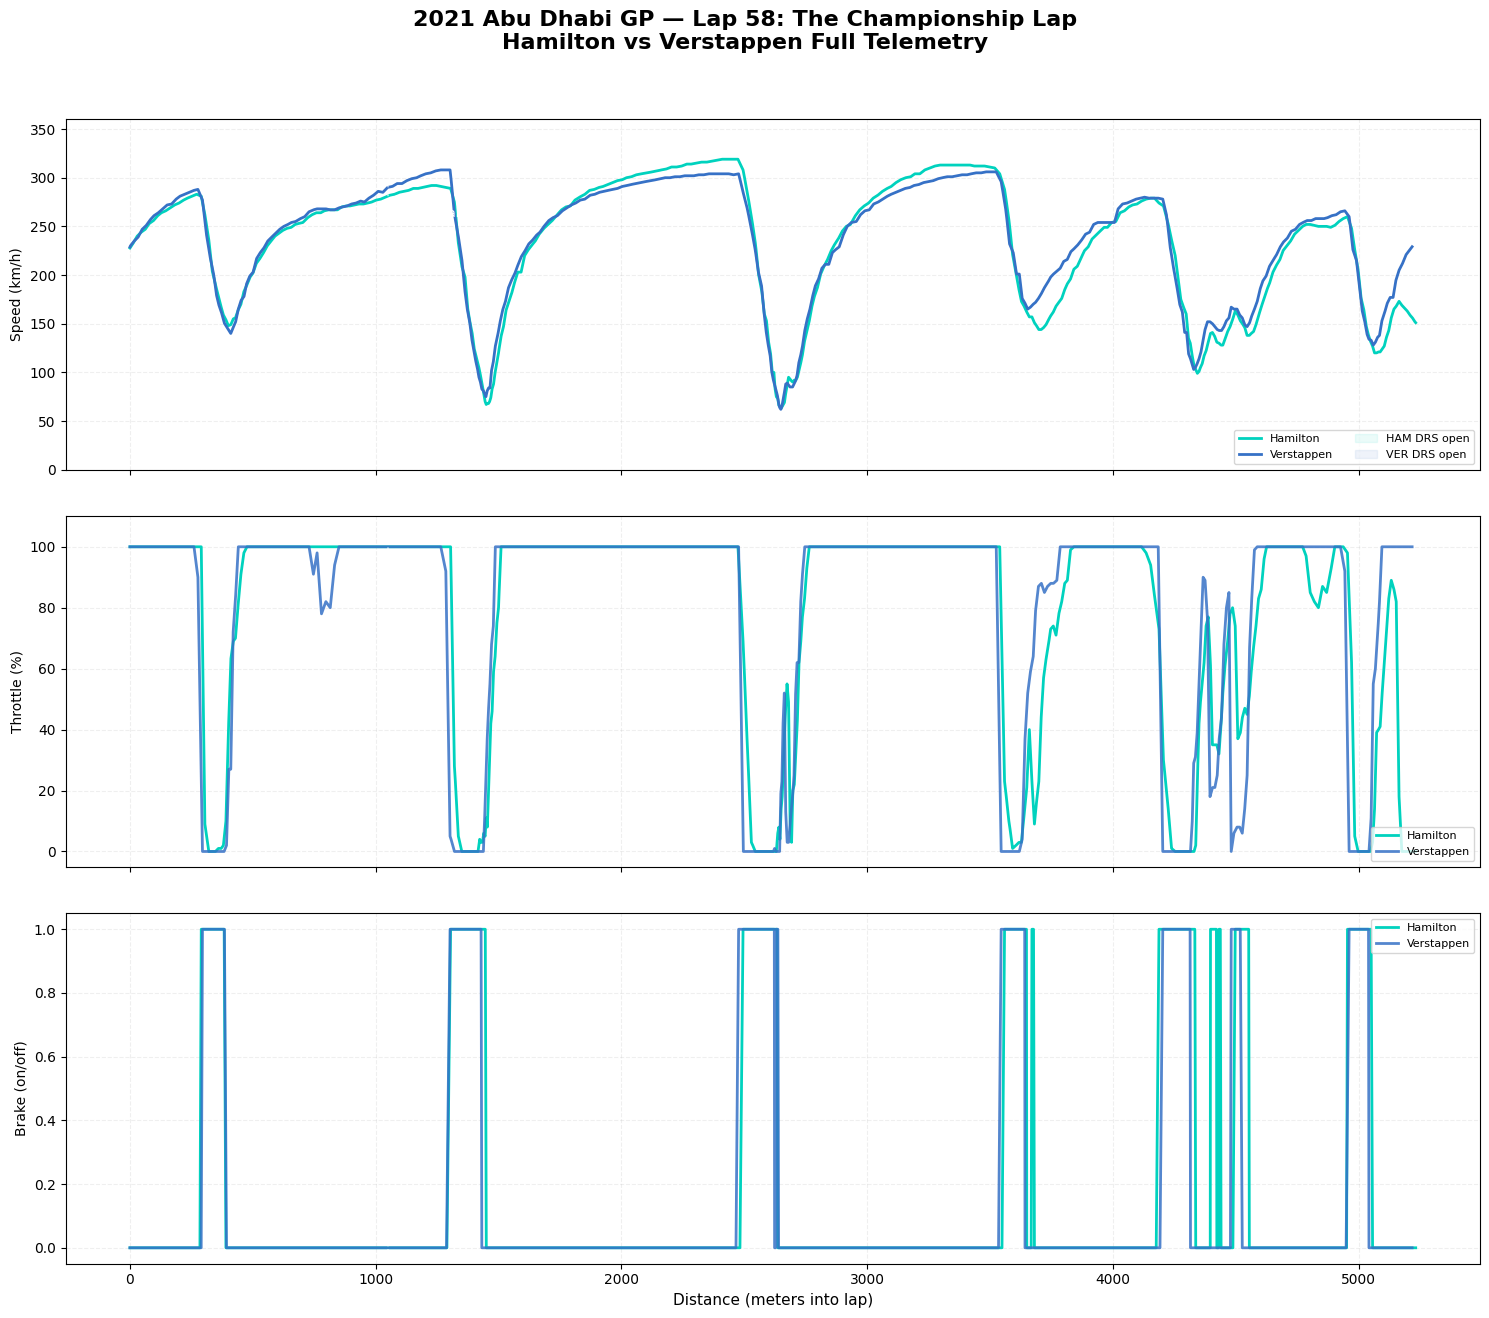

In [8]:
# ============================================================
# PHASE 3 — LAP 58 TELEMETRY DASHBOARD
# The exact lap the championship changed hands
# ============================================================

ham_lap58 = session.laps.pick_driver('HAM').pick_lap(58)
ver_lap58 = session.laps.pick_driver('VER').pick_lap(58)

ham_tel = ham_lap58.get_telemetry().add_distance()
ver_tel = ver_lap58.get_telemetry().add_distance()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 13), sharex=True)
fig.suptitle("2021 Abu Dhabi GP — Lap 58: The Championship Lap\nHamilton vs Verstappen Full Telemetry",
             fontsize=16, fontweight='bold', y=1.01)

HAM_COLOR = '#00D2BE'
VER_COLOR = '#3671C6'

# --- Speed + DRS ---
ax1.plot(ham_tel['Distance'], ham_tel['Speed'], color=HAM_COLOR, lw=2, label='Hamilton')
ax1.plot(ver_tel['Distance'], ver_tel['Speed'], color=VER_COLOR, lw=2, label='Verstappen')
ax1.fill_between(ham_tel['Distance'], 0, 350,
                 where=ham_tel['DRS'].isin([12, 14]),
                 color=HAM_COLOR, alpha=0.08, label='HAM DRS open')
ax1.fill_between(ver_tel['Distance'], 0, 350,
                 where=ver_tel['DRS'].isin([12, 14]),
                 color=VER_COLOR, alpha=0.08, label='VER DRS open')
ax1.axvline(x=1050, color='white', lw=1.2, linestyle=':', alpha=0.6)
ax1.annotate('Turn 5\nOvertake Zone', xy=(1050, 280), xytext=(1150, 260),
             color='white', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='white', lw=1.2))
ax1.set_ylabel("Speed (km/h)", fontsize=10)
ax1.set_title("Speed Trace + DRS Zones", fontsize=11, color='white', pad=8)
ax1.legend(loc='lower right', fontsize=8, ncol=2)
ax1.grid(True, linestyle='--', alpha=0.2)
ax1.set_ylim(0, 360)

# --- Throttle ---
ax2.plot(ham_tel['Distance'], ham_tel['Throttle'], color=HAM_COLOR, lw=2, label='Hamilton')
ax2.plot(ver_tel['Distance'], ver_tel['Throttle'], color=VER_COLOR, lw=2, label='Verstappen', alpha=0.85)
ax2.axvline(x=1050, color='white', lw=1.2, linestyle=':', alpha=0.6)
ax2.set_ylabel("Throttle (%)", fontsize=10)
ax2.set_title("Throttle Application", fontsize=11, color='white', pad=8)
ax2.legend(loc='lower right', fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.2)
ax2.set_ylim(-5, 110)

# --- Brake ---
ax3.plot(ham_tel['Distance'], ham_tel['Brake'], color=HAM_COLOR, lw=2, label='Hamilton')
ax3.plot(ver_tel['Distance'], ver_tel['Brake'], color=VER_COLOR, lw=2, label='Verstappen', alpha=0.85)
ax3.axvline(x=1050, color='white', lw=1.2, linestyle=':', alpha=0.6)
ax3.set_ylabel("Brake (on/off)", fontsize=10)
ax3.set_xlabel("Distance (meters into lap)", fontsize=11)
ax3.set_title("Braking Events", fontsize=11, color='white', pad=8)
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(True, linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()


In [10]:
# ============================================================
# FINAL SUMMARY — WHAT THE DATA TELLS US
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║       2021 ABU DHABI GP — DATA ANALYSIS CONCLUSIONS          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  PHASE 0 — THE MACRO STORY                                   ║
║  Hamilton led for 57 of 58 laps, building an 11-second       ║
║  gap before the Latifi safety car erased it entirely.        ║
║                                                              ║
║  PHASE 1 — RACE PACE                                         ║
║  Both drivers were evenly matched on raw pace all race.      ║
║  The VSC (L36) and Safety Car (L53) were the turning points. ║
║                                                              ║
║  PHASE 2 — TYRE STRATEGY                                     ║
║  Hamilton: Medium → Hard (1 stop, managed well)              ║
║  Verstappen: Soft → Hard → Soft (2 stops, fresh rubber)      ║
║                                                              ║
║  PHASE 2B — THE DECISIVE DELTA                               ║
║  Verstappen's fresh Softs were 0.578s/lap faster than        ║
║  Hamilton's dying Hards in the final stint.                  ║
║  Over 5 laps: ~2.89s structural pace advantage to VER.       ║
║                                                              ║
║  PHASE 3 — LAP 58 TELEMETRY                                  ║
║  Verstappen carried higher corner speed, got on throttle     ║
║  earlier, and braked later — all direct consequences of      ║
║  fresh tyre grip that Hamilton simply couldn't match.        ║
║                                                              ║
║  VERDICT                                                     ║
║  The controversy was real. But the data shows Verstappen     ║
║  had a structural physical advantage that made the           ║
║  overtake inevitable once he had track position.             ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════╗
║       2021 ABU DHABI GP — DATA ANALYSIS CONCLUSIONS          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  PHASE 0 — THE MACRO STORY                                   ║
║  Hamilton led for 57 of 58 laps, building an 11-second       ║
║  gap before the Latifi safety car erased it entirely.        ║
║                                                              ║
║  PHASE 1 — RACE PACE                                         ║
║  Both drivers were evenly matched on raw pace all race.      ║
║  The VSC (L36) and Safety Car (L53) were the turning points. ║
║                                                              ║
║  PHASE 2 — TYRE STRATEGY                                     ║
║  Hamilton: Medium → Hard (1 stop, managed well)              ║
║  Verstappen: Soft → Hard → Soft (2 stops, fresh rubber)      ║
║                       